# Giovaniello et al. 2025 Reproduce & Simulation


In [63]:
# Simulate Figure 1h and 1i from Giovanniello et al. (Nature, 2025)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import statsmodels.formula.api as smf

# Set random seed
np.random.seed(50)


In [64]:
# PARAMETERS / MOUSE GROUPS AND SESSION

n_mice = {
    'control_non_deg': 7, # 7 mice in control, non-degraded group
    'control_deg': 7, # 7 mice in control, degraded group
    'stress_non_deg': 7, # 7 mice in stress, non-degraded group
    'stress_deg': 8 # 8 mice in stress, degraded group
}
sessions = np.arange(1, 5) # 4 training sessions

print(n_mice)
print(sessions)

{'control_non_deg': 7, 'control_deg': 7, 'stress_non_deg': 7, 'stress_deg': 8}
[1 2 3 4]


In [65]:
# Group means ± SDs from paper

training_data = { # these are training session means and SDs from the paper's raw data, I got these numbers from uploading
                  # the raw data onto JASP
    1: {'control_deg': (2.140, 0.619), # Day 1 mean and SD for control, degraded group from paper raw data
        'control_non_deg': (1.630, 0.755), # Day 1 mean and SD for control, non-degraded group from paper raw data
        'stress_deg': (2.235, 0.666), # Day 1 mean and SD for stress, degraded group from paper raw data
        'stress_non_deg': (2.626, 1.056)}, # Day 1 mean and SD for stress, non-degraded group from paper raw data
    2: {'control_deg': (5.727, 2.088), # Day 2 mean and SD for control, degraded group from paper raw data
        'control_non_deg': (6.240, 3.677), # Day 2 mean and SD for control, non-degraded group from paper raw data
        'stress_deg': (4.484, 2.296), # Day 2 mean and SD for stress, degraded group from paper raw data
        'stress_non_deg': (4.899, 2.223)}, # Day 2 mean and SD for stress, non-degraded group from paper raw data
    3: {'control_deg': (10.28, 2.460), # Day 3 mean and SD for control, degraded group from paper raw data
        'control_non_deg': (9.104, 2.770), # Day 3 mean and SD for control, non-degraded group from paper raw data
        'stress_deg': (10.20, 2.811), # Day 3 mean and SD for stress, degraded group from paper raw data
        'stress_non_deg': (10.98, 3.392)}, # Day 3 mean and SD for stress, non-degraded group from paper raw data
    4: {'control_deg': (15.37, 2.336), # Day 4 mean and SD for control, degraded group from paper raw data
        'control_non_deg': (16.69, 5.146), # Day 4 mean and SD for control, non-degraded group from paper raw data
        'stress_deg': (14.98, 4.992), # Day 4 mean and SD for stress, degraded group from paper raw data
        'stress_non_deg': (17.38, 6.069)} # Day 4 mean and SD for stress, non-degraded group from paper raw data
}

degradation_data = { # these are degradation session means and SDs from the paper's raw data, I gt these numbers from       
                     # uploading the raw data onto JASP
    'Control Non-degraded': {'mean': 15.371, 'sd': 5.401, 'n': 7}, 
    'Control Degraded': {'mean': 3.486, 'sd': 1.852, 'n': 7}, 
    'Stress Non-degraded': {'mean': 12.225, 'sd': 5.537, 'n': 7}, 
    'Stress Degraded': {'mean': 11.714, 'sd': 4.730, 'n': 8}
}


In [66]:
# SIMULATE TRAINING DATA (Fig. 1h)
# From the means ± SDs

training_sim = [] # to hold training data from simulation

for session, vals in training_data.items():
    for group, (mean, sd) in vals.items(): 
        rates = np.random.normal(mean, sd, n_mice[group]) # simulate press rates
        for r in rates: 
            stress = 'Control' if 'control' in group else 'Stress' # determine stress condition
            contingency = 'Degraded' if 'deg' in group and 'non' not in group else 'Non-degraded' # determine contingency condition
            training_sim.append({ # use dict to append to lst the different columns
                'Session': session,
                'PressRate': r,
                'Stress': stress,
                'Contingency': contingency
            })

training_df = pd.DataFrame(training_sim)
print(training_sim)
print(training_df.head(116))

# Save trainining data to CSV
training_df.to_csv('output.csv', index=False)

[{'Session': 1, 'PressRate': 1.1741420447248192, 'Stress': 'Control', 'Contingency': 'Degraded'}, {'Session': 1, 'PressRate': 2.120824863449775, 'Stress': 'Control', 'Contingency': 'Degraded'}, {'Session': 1, 'PressRate': 1.7556453056179904, 'Stress': 'Control', 'Contingency': 'Degraded'}, {'Session': 1, 'PressRate': 1.2334246796602044, 'Stress': 'Control', 'Contingency': 'Degraded'}, {'Session': 1, 'PressRate': 3.0139946493860736, 'Stress': 'Control', 'Contingency': 'Degraded'}, {'Session': 1, 'PressRate': 1.8449028031871486, 'Stress': 'Control', 'Contingency': 'Degraded'}, {'Session': 1, 'PressRate': 1.6568895565979742, 'Stress': 'Control', 'Contingency': 'Degraded'}, {'Session': 1, 'PressRate': 2.4380521400354978, 'Stress': 'Control', 'Contingency': 'Non-degraded'}, {'Session': 1, 'PressRate': 0.6618690901034145, 'Stress': 'Control', 'Contingency': 'Non-degraded'}, {'Session': 1, 'PressRate': 0.6277534297237128, 'Stress': 'Control', 'Contingency': 'Non-degraded'}, {'Session': 1, 'Pr

In [106]:
# SIMULATE TRAINING DATA (Fig. 1h)
# From the means ± SDs

training_sim = [] # to hold training data from simulation

# Create stable subject IDs
subjects_by_group = {
    group: [f"{group}_{i}" for i in range(n)]
    for group, n in n_mice.items()
}

for session, vals in training_data.items():
    for group, (mean, sd) in vals.items():
        subjects = subjects_by_group[group]
        # Simulate press rates
        rates = np.random.normal(mean, sd, len(subjects))
        # Remove negative values (press rates can't be negative)
        rates = np.clip(rates, 0, None)
        
        stress = 'Control' if 'control' in group else 'Stress'
        contingency = 'Degraded' if ('deg' in group and 'non' not in group) else 'Non-degraded'
        
        for subj, rate in zip(subjects, rates):
            training_sim.append({
                'Session': session,
                'Subject': subj,
                'PressRate': rate,
                'Stress': stress,
                'Contingency': contingency
            })

training_df = pd.DataFrame(training_sim)
print(training_df.head(40))

# Save training data to CSV
training_df.to_csv('output.csv', index=False)

    Session            Subject  PressRate   Stress   Contingency
0         1      control_deg_0   2.919248  Control      Degraded
1         1      control_deg_1   3.201798  Control      Degraded
2         1      control_deg_2   1.821259  Control      Degraded
3         1      control_deg_3   1.191279  Control      Degraded
4         1      control_deg_4   1.971219  Control      Degraded
5         1      control_deg_5   2.967052  Control      Degraded
6         1      control_deg_6   3.459530  Control      Degraded
7         1  control_non_deg_0   1.963304  Control  Non-degraded
8         1  control_non_deg_1   1.738584  Control  Non-degraded
9         1  control_non_deg_2   0.295294  Control  Non-degraded
10        1  control_non_deg_3   0.912131  Control  Non-degraded
11        1  control_non_deg_4   0.932485  Control  Non-degraded
12        1  control_non_deg_5   1.291730  Control  Non-degraded
13        1  control_non_deg_6   1.524066  Control  Non-degraded
14        1       stress_

In [101]:
# SIMULATE TRAINING DATA (Fig. 1h)
# From the means ± SDs

training_sim = [] # to hold training data from simulation

subjects_by_group = { # create subject IDs 
    group: [f"{group}_{i}" for i in range(n)]
    for group, n in n_mice.items()
}

for session, vals in training_data.items():
    for group, (mean, sd) in vals.items(): 
        rates = np.random.normal(mean, sd, n_mice[group]) # simulate press rates
        for r in rates: 
            stress = 'Control' if 'control' in group else 'Stress' # determine stress condition
            contingency = 'Degraded' if 'deg' in group and 'non' not in group else 'Non-degraded' # determine contingency condition
            training_sim.append({ # use dict to append to lst the different columns
                'Session': session,
                'PressRate': r,
                'Subject': subjects_by_group,
                'Stress': stress,
                'Contingency': contingency
            })

training_df = pd.DataFrame(training_sim)
print(training_sim)
print(training_df.head(116))

# Save trainining data to CSV
training_df.to_csv('output.csv', index=False)

[{'Session': 1, 'PressRate': 1.9950383209703995, 'Subject': {'control_non_deg': ['control_non_deg_0', 'control_non_deg_1', 'control_non_deg_2', 'control_non_deg_3', 'control_non_deg_4', 'control_non_deg_5', 'control_non_deg_6'], 'control_deg': ['control_deg_0', 'control_deg_1', 'control_deg_2', 'control_deg_3', 'control_deg_4', 'control_deg_5', 'control_deg_6'], 'stress_deg': ['stress_deg_0', 'stress_deg_1', 'stress_deg_2', 'stress_deg_3', 'stress_deg_4', 'stress_deg_5', 'stress_deg_6', 'stress_deg_7'], 'stress_non_deg': ['stress_non_deg_0', 'stress_non_deg_1', 'stress_non_deg_2', 'stress_non_deg_3', 'stress_non_deg_4', 'stress_non_deg_5', 'stress_non_deg_6']}, 'Stress': 'Control', 'Contingency': 'Degraded'}, {'Session': 1, 'PressRate': 1.2469342688577045, 'Subject': {'control_non_deg': ['control_non_deg_0', 'control_non_deg_1', 'control_non_deg_2', 'control_non_deg_3', 'control_non_deg_4', 'control_non_deg_5', 'control_non_deg_6'], 'control_deg': ['control_deg_0', 'control_deg_1', 'co

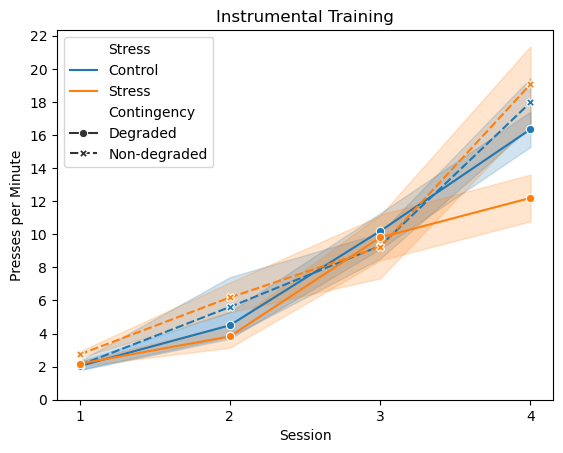

In [105]:
# PLOT SIMULATED TRAINING DATA

plt.figure 
sns.lineplot(
    data=training_df,
    x='Session', y='PressRate',
    hue='Stress', style='Contingency',
    markers=True, errorbar=('se'),
)

plt.title("Instrumental Training")
plt.xticks([1, 2, 3, 4])
plt.yticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22])
plt.ylabel("Presses per Minute")
plt.show()


In [103]:
# Need to do RM ANOVA here

In [114]:
# Create a combined Group factor for mixed_anova (which only supports one between factor)
training_df['Group'] = training_df['Stress'] + ' ' + training_df['Contingency']

anova = pg.mixed_anova(
    dv='PressRate',
    within='Session',
    between='Group',
    subject='Subject',
    data=training_df
)

print(anova)

        Source           SS  DF1  DF2           MS          F         p-unc  \
0        Group    57.396646    3   25    19.132215   2.326798  9.898103e-02   
1      Session  3065.871414    3   75  1021.957138  88.826223  1.273993e-24   
2  Interaction   163.479788    9   75    18.164421   1.578811  1.371389e-01   

      p-GG-corr       np2       eps sphericity   W-spher       p-spher  
0           NaN  0.218271       NaN        NaN       NaN           NaN  
1  9.048095e-16  0.780367  0.589032      False  0.243411  4.342957e-07  
2           NaN  0.159280       NaN        NaN       NaN           NaN  


In [ ]:
# SIMULATE CONTINGENCY DEGRADATION DATA (Fig. 1i)
# From real means ± SDs

degradation_sim = [] # to hold lever press degradation data from simulation

for group, params in degradation_data.items(): 
    mean, sd, n = params['mean'], params['sd'], params['n'] 
    rates = np.random.normal(mean, sd, n) # simulate press rates for degradation groups
    stress = 'Control' if 'Control' in group else 'Stress' 
    contingency = 'Degraded' if 'Degraded' in group else 'Non-degraded'
    for r in rates:
        degradation_sim.append({ # use dict to append to lst the different columns
            'Group': group,
            'Stress': stress,
            'Contingency': contingency,
            'PressRate': r
        })

degradation_df = pd.DataFrame(degradation_sim) # create dataframe
degradation_df.head()
print(degradation_df) # sanity check 

# Save degradation data to CSV for analysis on JASP
degradation_df.to_csv('degradation_output.csv', index=False)

                   Group   Stress   Contingency  PressRate
0   Control Non-degraded  Control  Non-degraded   6.136125
1   Control Non-degraded  Control  Non-degraded   6.817603
2   Control Non-degraded  Control  Non-degraded   9.427255
3   Control Non-degraded  Control  Non-degraded   9.120652
4   Control Non-degraded  Control  Non-degraded  25.136250
5   Control Non-degraded  Control  Non-degraded   9.369524
6   Control Non-degraded  Control  Non-degraded  20.072113
7       Control Degraded  Control      Degraded   4.873098
8       Control Degraded  Control      Degraded   4.800054
9       Control Degraded  Control      Degraded   4.071509
10      Control Degraded  Control      Degraded   2.044747
11      Control Degraded  Control      Degraded   2.493399
12      Control Degraded  Control      Degraded   1.312063
13      Control Degraded  Control      Degraded   1.754757
14   Stress Non-degraded   Stress  Non-degraded   6.134080
15   Stress Non-degraded   Stress  Non-degraded  12.0699

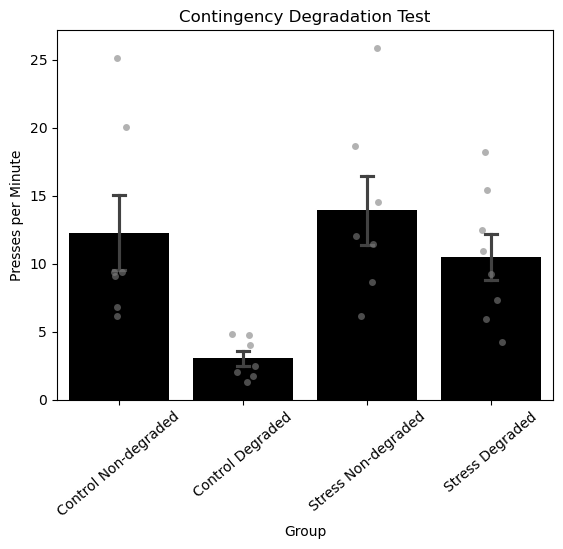

In [36]:
# PLOT SIMULATED CONTINGENCY DEGRADATION DATA

plt.figure
sns.barplot(
    data=degradation_df, x='Group', y='PressRate',
    capsize=.1, errorbar='se', color='black'
)

sns.stripplot(
    data=degradation_df, x='Group', y='PressRate',
    jitter=True, alpha=0.6, color='grey', size=5
)
plt.title("Contingency Degradation Test")
plt.ylabel("Presses per Minute")
plt.xticks(rotation=40)
plt.show()


In [ ]:
# Need to do ANOVA here

In [20]:
# Contingency degradation two-way ANOVA

deg_anova = pg.anova(
    data=degradation_df,
    dv='PressRate',
    between=['Group', 'Contingency']
)

print(deg_anova)

                Source           SS    DF           MS          F  \
0                Group   661.290560   3.0   220.430187   7.284701   
1          Contingency   220.430187   1.0   220.430187   7.284701   
2  Group * Contingency  3140.234891   3.0  1046.744964  34.592466   
3             Residual   756.483344  25.0    30.259334        NaN   

          p-unc       np2  
0  1.228612e-02  0.466429  
1  1.228612e-02  0.225639  
2  4.696932e-09  0.805867  
3           NaN       NaN  


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1
  warnings.warn('covariance of constraints does not have full '
